# Forecasting `Ziekteverzuimpercentage` — Basic Time-Series Model

A first, deliberately minimal end-to-end pipeline that forecasts the national quarterly sickness-absence rate (`Ziekteverzuimpercentage_1`) **3 quarters ahead** using the gold-layer feature store.

## Approach

**Data.** A single quarterly time series (1996 Q1 onward, 120 observations) of the Dutch national sickness-absence rate, joined with 61 macro-labour features from the gold-layer feature store (`master_data_ml_preprocessed`).

**Forecast horizon.** Three quarters ahead. To make this an honest forecasting setup — rather than a contemporaneous mapping — the regression is trained on **features lagged by 3 quarters**: at time `t`, the model only sees information that was already available at time `t-3`.

**Train / test split.** Chronological, *not* random — random splits leak future information into the training set. The last **12 quarters (3 years)** are held out as the test set. This window covers four non-overlapping 3-quarter forecasts and leaves 108 quarters for training.

**Models.**
- **A — Naive seasonal baseline:** `ŷ_t = y_{t-4}` (same quarter, one year earlier). No fitting required. Serves as the "is this even worth modelling?" benchmark.
- **B — Linear Regression:** `sklearn.linear_model.LinearRegression` on the 61 lagged features. No scaling, no regularisation, no feature selection — all deliberately deferred to later iterations.

**Evaluation.** MAE, RMSE and R² on the 12-quarter hold-out, plus a visual actual-vs-predicted plot. The interesting question is not the absolute error but whether **Model B beats Model A** — if it doesn't, the features (or the linear specification) aren't pulling their weight.

**What this notebook is not.** It is not yet a competitive forecast: no feature selection, no scaling, no cross-validation, no recursive multi-step strategy, no non-linear models. Those are the natural follow-up iterations once the pipeline below runs cleanly end-to-end.

## 1 · Environment setup

Imports the project's data, plotting and modelling stack, wires the repo root into `sys.path` so that `from src.*` works inside the notebook, and pulls the two project-wide constants we will rely on — the path to the gold SQLite database and the name of the target column. Also declares `STRUCTURAL_COLS`: the set of columns that act as identifiers / metadata and must never be fed to a model as features.

In [5]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold

# Make src/ importable from notebook context
PROJECT_ROOT = Path().resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DIR_DB_GOLD, ML_TARGET_COLUMN

# ── Structural columns — never treated as ML features ──────────────────────
STRUCTURAL_COLS = {"silver_id", "quarter", "year", "period_enddate", "BedrijfstakkenBranchesSBI2008"}

print(f"Project root : {PROJECT_ROOT}")
print(f"Gold DB      : {DIR_DB_GOLD}")
print(f"Target column: {ML_TARGET_COLUMN}")

Project root : C:\Users\User\Documents\GitHub\eaisi-uwv
Gold DB      : C:\Users\User\Documents\GitHub\eaisi-uwv\data\3_gold\gold_data.db
Target column: Ziekteverzuimpercentage_1


## 2 · Extract the gold-layer feature store

Instantiates `DataExtractor` against the `master_data_ml_preprocessed` table and pulls a flat DataFrame in **discovery mode** (`feature_groups=None`) — i.e. *all* columns rather than a curated subset. The result `df_raw` has one row per quarter at the national / all-industry level, with the target alongside every candidate feature.

In [6]:
from src.ml_engineering.ml_1_data_extraction import DataExtractor

extractor = DataExtractor(db_path=DIR_DB_GOLD, table_name="master_data_ml_preprocessed")
df_raw = extractor.extract(target_column=ML_TARGET_COLUMN, feature_groups=None)  # discovery: all columns

print(f"Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
df_raw.head(3)

⚙️ SBI mode=all-industry (BedrijfskenmerkenSBI2008_T001081) | 120 quarterly rows
✅ Extraction complete | mode=discovery | sbi=all-industry | features=61 | rows=120


Shape: 120 rows × 65 columns


,period_enddate,year,quarter,Ziekteverzuimpercentage_1,trend_index,Banen_2_A045285_3000,Banen_2_A045285_4000,Banen_2_A045286_3000,Banen_2_A045286_4000,Banen_7_A045285_3000,...,GewerkteUren_5_A045285,GewerkteUren_5_A045286,WerkzamePersonenSeizoengecorrigeerd_2_A045285,WerkzamePersonenSeizoengecorrigeerd_2_A045286,WerkzamePersonenSeizoengecorrigeerd_9_A045285,WerkzamePersonenSeizoengecorrigeerd_9_A045286,WerkzamePersonen_1_A045285,WerkzamePersonen_1_A045286,WerkzamePersonen_7_A045285,WerkzamePersonen_7_A045286
0,1996-03-31 00:00:00.000000,1996.0,1.0,5.5,1.0,4295.0,3895.0,1098.0,1088.5,4296.0,...,216.866667,44.733333,589.733333,102.600000,0.800000,-0.066667,582.933333,102.000000,13.2,0.733333
1,1996-06-30 00:00:00.000000,1996.0,2.0,4.6,2.0,4295.0,3895.0,1098.0,1088.5,4296.0,...,202.733333,46.600000,594.066667,102.600000,4.333333,0.066667,596.466667,102.733333,15.2,0.266667
2,1996-09-30 00:00:00.000000,1996.0,3.0,4.0,3.0,4295.0,3895.0,1098.0,1088.5,4296.0,...,198.866667,43.866667,597.866667,102.733333,3.800000,0.266667,604.133333,102.866667,14.8,0.400000


## 3 · Column bookkeeping

Sorts every column of `df_raw` into one of four buckets — `structural`, `target`, `sector_filter (OHE)`, `feature` — so the downstream cells can cleanly refer to `feature_cols` without leaking metadata or the target into the feature matrix. The summary table also confirms how many features survived after exclusions.

In [7]:
SBI_FILTER_PREFIX = "BedrijfskenmerkenSBI2008_"

structural    = [c for c in df_raw.columns if c in STRUCTURAL_COLS]
target_col    = [ML_TARGET_COLUMN]
sector_filter = [c for c in df_raw.columns if c.startswith(SBI_FILTER_PREFIX)]

# Feature columns: everything else — exclude structural, target, and sector-filter OHE
feature_cols  = [
    c for c in df_raw.columns
    if c not in STRUCTURAL_COLS
    and c != ML_TARGET_COLUMN
    and not c.startswith(SBI_FILTER_PREFIX)
]

summary = pd.DataFrame({
    "Bucket":  ["structural", "target", "sector_filter (OHE)", "feature"],
    "Count":   [len(structural), len(target_col), len(sector_filter), len(feature_cols)],
    "Examples": [
        ", ".join(structural[:3]),
        ML_TARGET_COLUMN,
        ", ".join(sector_filter[:3]),
        ", ".join(feature_cols[:3]),
    ],
})
print(summary.to_string(index=False))
print(f"\nTotal ML features (excl. structural + target + sector_filter): {len(feature_cols)}")

example_col = sector_filter[0] if sector_filter else "BedrijfskenmerkenSBI2008_XXX"
print(f"\nSector filter columns ({len(sector_filter)}) — use to restrict analysis to one SBI sector:")
print(f"  e.g. df_raw[df_raw[{example_col!r}] == 1]")

             Bucket  Count                                                Examples
         structural      3                           period_enddate, year, quarter
             target      1                               Ziekteverzuimpercentage_1
sector_filter (OHE)      0                                                        
            feature     61 trend_index, Banen_2_A045285_3000, Banen_2_A045285_4000

Total ML features (excl. structural + target + sector_filter): 61

Sector filter columns (0) — use to restrict analysis to one SBI sector:
  e.g. df_raw[df_raw['BedrijfskenmerkenSBI2008_XXX'] == 1]


## 4 · Modelling imports

The few extra `sklearn` pieces needed for the basic pipeline: `LinearRegression` for the model itself and three metric helpers (`mean_absolute_error`, `mean_squared_error`, `r2_score`) for evaluation.

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 5 · Build a time-ordered DataFrame

Copies `df_raw`, converts `period_enddate` to a real `pandas.Timestamp` column, sorts the rows chronologically, and promotes the date column to the **DatetimeIndex** of `df`. From here on `df` is the canonical, time-ordered version of the data — needed for honest chronological splits and time-axis plots.

In [9]:
# Sort chronologically and set a proper DatetimeIndex (needed for time-aware splits and plots).
df = df_raw.copy()
df["period_enddate"] = pd.to_datetime(df["period_enddate"])
df = df.sort_values("period_enddate").set_index("period_enddate")

print(f"Rows       : {len(df)}")
print(f"Date range : {df.index.min().date()} → {df.index.max().date()}")

Rows       : 120
Date range : 1996-03-31 → 2025-12-31


## 6 · Chronological train / test split

Holds out the **last 12 quarters (3 years)** as the test set and uses everything before that for training. The split is purely positional (`df.iloc[:-TEST_SIZE]` / `df.iloc[-TEST_SIZE:]`) because the index is already time-ordered — no shuffling, no random seed. The printed date ranges are a quick sanity check that the split landed where expected.

In [10]:
# Chronological hold-out: last 12 quarters = 3 years = 4 non-overlapping 3Q forecasts.
TEST_SIZE = 12

train = df.iloc[:-TEST_SIZE]
test  = df.iloc[-TEST_SIZE:]

X_train, X_test = train[feature_cols], test[feature_cols]
y_train, y_test = train[ML_TARGET_COLUMN], test[ML_TARGET_COLUMN]

print(f"Train: {X_train.shape[0]} rows × {X_train.shape[1]} features  ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test : {X_test.shape[0]} rows × {X_test.shape[1]} features  ({test.index.min().date()} → {test.index.max().date()})")

Train: 108 rows × 61 features  (1996-03-31 → 2022-12-31)
Test : 12 rows × 61 features  (2023-03-31 → 2025-12-31)


## 7 · Model A — Naive seasonal baseline

The cheapest possible forecast: predict each test quarter as the value of the *same quarter one year earlier* (`y_pred = y.shift(4)`). No fitting, no features — just historical look-up. Its only job is to set a benchmark that any "real" model has to beat to justify its existence.

In [11]:
# ── Model A: Naive seasonal baseline (same quarter, one year earlier) ────
# Prediction for quarter t = actual value at quarter t-4.
y_full = df[ML_TARGET_COLUMN]
y_pred_naive = y_full.shift(4).iloc[-TEST_SIZE:]

print(f"Naive predictions for the last {TEST_SIZE} quarters:")
print(pd.DataFrame({"actual": y_test.values, "naive_pred": y_pred_naive.values}, index=test.index))

Naive predictions for the last 12 quarters:
                actual  naive_pred
period_enddate                    
2023-03-31         5.7         6.3
2023-06-30         5.0         5.4
2023-09-30         4.8         5.0
2023-12-31         5.5         5.6
2024-03-31         5.5         5.7
2024-06-30         5.1         5.0
2024-09-30         4.9         4.8
2024-12-31         5.4         5.5
2025-03-31         5.8         5.5
2025-06-30         5.2         5.1
2025-09-30         5.1         4.9
2025-12-31         5.6         5.4


## 8 · Model B — LinearRegression with 3-quarter lagged features

Shifts every feature by 3 quarters so that the matrix `X_lagged_t` only contains information that was known at time `t-3`. The model therefore learns the relationship `y_t = f(X_{t-3})` directly — a **direct 3-step-ahead** forecasting setup, no recursive prediction needed. The first 3 rows (where the lagged features are NaN) are dropped before splitting and fitting.

In [12]:
# ── Model B: LinearRegression with 3-quarter lagged features ──────────────
# To forecast 3 quarters ahead, the model learns y_t = f(X_{t-3}).
LAG = 3
X_lagged = df[feature_cols].shift(LAG)

# Align: drop the first LAG rows where lagged features are NaN.
mask = X_lagged.notna().all(axis=1)
X_lagged_aligned = X_lagged.loc[mask]
y_aligned        = df.loc[mask, ML_TARGET_COLUMN]

# Same chronological split — last 12 quarters as test.
X_train_lag = X_lagged_aligned.iloc[:-TEST_SIZE]
X_test_lag  = X_lagged_aligned.iloc[-TEST_SIZE:]
y_train_lag = y_aligned.iloc[:-TEST_SIZE]
y_test_lag  = y_aligned.iloc[-TEST_SIZE:]

lr = LinearRegression()
lr.fit(X_train_lag, y_train_lag)
y_pred_lr = lr.predict(X_test_lag)

print(f"Lagged train shape: {X_train_lag.shape}")
print(f"Lagged test  shape: {X_test_lag.shape}")
print(f"First test prediction: {y_pred_lr[0]:.3f}  (actual: {y_test_lag.iloc[0]:.3f})")

Lagged train shape: (105, 61)
Lagged test  shape: (12, 61)
First test prediction: 7.996  (actual: 5.700)


## 9 · Hold-out metrics

Computes MAE, RMSE and R² for both models on the 12-quarter hold-out and prints them as a single comparison table. The interesting numbers are *relative*: does the LinearRegression beat the seasonal-naive baseline on at least one of the three metrics?

In [13]:
def score(y_true, y_pred):
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²":   r2_score(y_true, y_pred),
    }

metrics = pd.DataFrame(
    [score(y_test, y_pred_naive), score(y_test, y_pred_lr)],
    index=["Naive seasonal (y_{t-4})", "LinearRegression (lag 3Q)"],
).round(4)

print("Hold-out metrics (last 12 quarters):")
print(metrics.to_string())

Hold-out metrics (last 12 quarters):
                              MAE    RMSE       R²
Naive seasonal (y_{t-4})   0.2167  0.2614   0.3051
LinearRegression (lag 3Q)  2.9329  3.1349 -98.9392


## 10 · Actual vs predicted

A single plot of the 12-quarter hold-out: the true target in solid black, the naive seasonal prediction in dashed orange, and the LinearRegression prediction in dashed blue. Visual inspection often reveals failure modes that the aggregate metrics hide — e.g. one model tracking the level but missing the swings, or systematically over- or under-shooting in a specific quarter.

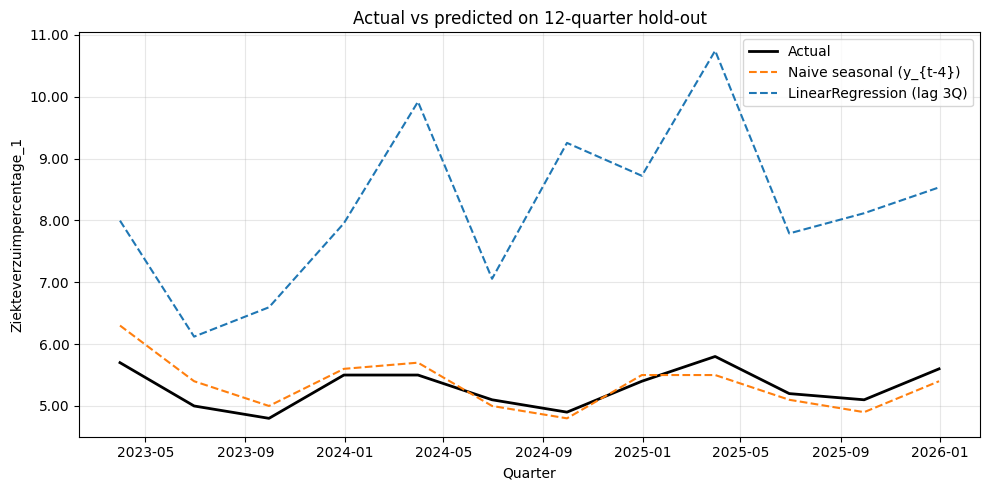

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(test.index, y_test.values,       label="Actual",                    color="black", linewidth=2)
ax.plot(test.index, y_pred_naive.values, label="Naive seasonal (y_{t-4})",  color="tab:orange", linestyle="--")
ax.plot(test.index, y_pred_lr,           label="LinearRegression (lag 3Q)", color="tab:blue",   linestyle="--")

ax.set_title("Actual vs predicted on 12-quarter hold-out")
ax.set_xlabel("Quarter")
ax.set_ylabel(ML_TARGET_COLUMN)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()